In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

INPUT_DIR  = '/content/drive/MyDrive/lung_sound/stethoscope'
OUTPUT_DIR = '/content/drive/MyDrive/lung_sound/smartphone_converted'

from pathlib import Path
Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)
print('경로 설정 완료!')

Mounted at /content/drive
경로 설정 완료!


In [2]:
!pip install librosa scipy -q
import librosa
import numpy as np
from scipy.interpolate import PchipInterpolator
from scipy.io.wavfile import write as wav_write
import random
import pandas as pd

SNR_DB = 15
print(f'SNR: {SNR_DB}dB')

SNR: 15dB


In [3]:
# ESC-50 로드
ESC50_DIR = '/content/drive/MyDrive/lung_sound/ESC-50-master/audio'
ESC50_CSV = '/content/drive/MyDrive/lung_sound/ESC-50-master/meta/esc50.csv'

df = pd.read_csv(ESC50_CSV)
wanted = ['breathing', 'coughing', 'footsteps', 'door_wood_knock', 'clock_tick', 'rain', 'wind']
filtered = df[df['category'].isin(wanted)]
esc50_files = [str(Path(ESC50_DIR) / fname) for fname in filtered['filename'].tolist()]
print(f'사용할 ESC-50 파일 수: {len(esc50_files)}')

사용할 ESC-50 파일 수: 280


In [ ]:
# 최초(700Hz) EQ 커브
def make_eq_curve(freqs):
    freq_points = [0, 100, 300, 700, 2000, 20000]
    db_points   = [-10, -8, -2, 0, +2, +5]
    interpolator = PchipInterpolator(freq_points, db_points)
    db_curve = interpolator(freqs)
    gain = 10 ** (db_curve / 20)
    return gain

def apply_eq(audio, sample_rate):
    fft_result = np.fft.rfft(audio)
    freqs = np.fft.rfftfreq(len(audio), d=1.0 / sample_rate)
    gain = make_eq_curve(freqs)
    fft_result *= gain
    return np.fft.irfft(fft_result, n=len(audio))

def add_noise(audio, snr_db=15):
    signal_power = np.mean(audio ** 2)
    noise_power  = signal_power / (10 ** (snr_db / 10))
    noise = np.random.normal(0, np.sqrt(noise_power), len(audio))
    return audio + noise

def add_esc_noise(audio, sr, esc50_files, snr_min=15, snr_max=20, prob=0.5):
    if random.random() > prob:
        return audio, False, None
    noise_path = random.choice(esc50_files)
    noise, noise_sr = librosa.load(noise_path, sr=sr, mono=True)
    if len(noise) < len(audio):
        noise = np.tile(noise, int(np.ceil(len(audio) / len(noise))))
    noise = noise[:len(audio)]
    snr_db = random.uniform(snr_min, snr_max)
    signal_power = np.mean(audio ** 2)
    noise_power  = np.mean(noise ** 2)
    if noise_power > 0:
        scale = np.sqrt(signal_power / (10 ** (snr_db / 10) * noise_power))
        audio = audio + scale * noise
    return audio, True, Path(noise_path).name

def transfer_domain(wav_path, esc50_files, snr_db=15):
    audio, sr = librosa.load(wav_path, sr=None, mono=True)
    converted = apply_eq(audio, sr)
    converted = add_noise(converted, snr_db=snr_db)
    converted, esc_applied, esc_file = add_esc_noise(converted, sr, esc50_files)
    max_val = np.max(np.abs(converted))
    if max_val > 0:
        converted = converted / max_val * 0.9
    return converted, sr, esc_applied, esc_file

print('함수 정의 완료!')

함수 정의 완료!


In [5]:
# 전체 변환 실행
wav_files = sorted(list(Path(INPUT_DIR).glob('*.wav')))
print(f'변환할 파일 수: {len(wav_files)}')

success, fail = 0, 0
log_rows = []

for wav_path in wav_files:
    try:
        converted, sr, esc_applied, esc_file = transfer_domain(str(wav_path), esc50_files, snr_db=SNR_DB)
        out_path = Path(OUTPUT_DIR) / wav_path.name
        wav_write(str(out_path), sr, (converted * 32767).astype(np.int16))
        success += 1
        log_rows.append({'filename': wav_path.name, 'esc_applied': esc_applied, 'esc_file': esc_file})
    except Exception as e:
        print(f'[ERR] {wav_path.name} → {e}')
        fail += 1
    if (success + fail) % 100 == 0:
        print(f'  {success + fail}/{len(wav_files)} 완료')

print(f'\n✅ 변환 완료! 성공: {success}개 / 실패: {fail}개')

log_df = pd.DataFrame(log_rows)
log_df.to_csv('/content/drive/MyDrive/lung_sound/esc_noise_log_final.csv', index=False)
print(log_df['esc_applied'].value_counts())

변환할 파일 수: 920
  100/920 완료
  200/920 완료
  300/920 완료
  400/920 완료
  500/920 완료
  600/920 완료
  700/920 완료
  800/920 완료
  900/920 완료

✅ 변환 완료! 성공: 920개 / 실패: 0개
esc_applied
False    490
True     430
Name: count, dtype: int64


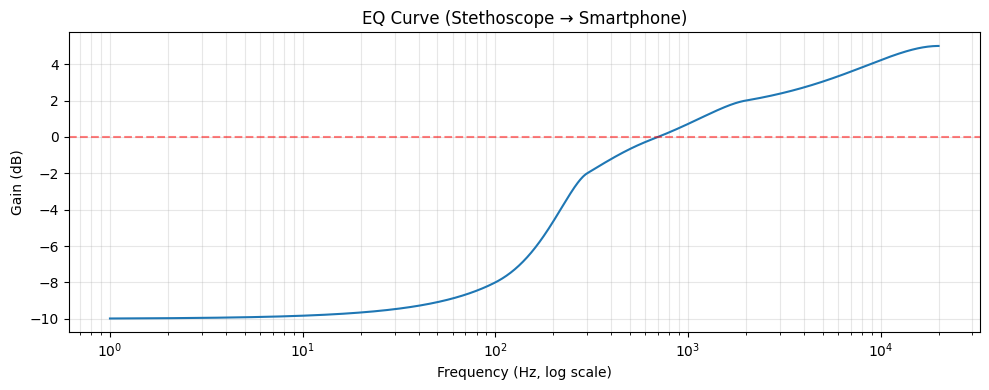

    Hz        dB
    20     -9.65
    50     -9.08
   100     -7.99
   150     -6.51
   300     -2.01
   500     -0.66
   700      0.00
  1000      0.71
  1500      1.58
  2000      2.00
  4000      2.73
  6000      3.33
 10000      4.22
 20000      5.00


In [6]:
import matplotlib.pyplot as plt

freqs = np.logspace(np.log10(1), np.log10(20000), 1000)
gain  = make_eq_curve(freqs)
db    = 20 * np.log10(np.clip(gain, 1e-10, None))

plt.figure(figsize=(10, 4))
plt.plot(freqs, db)
plt.xscale('log')
plt.xlabel('Frequency (Hz, log scale)')
plt.ylabel('Gain (dB)')
plt.title('EQ Curve (Stethoscope → Smartphone)')
plt.grid(True, which='both', alpha=0.3)
plt.axhline(y=0, color='r', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/lung_sound/eq_curve_final.png', dpi=150, bbox_inches='tight')  # ← 추가
plt.show()

print(f"{'Hz':>6}  {'dB':>8}")
for f in [20, 50, 100, 150, 300, 500, 700, 1000, 1500, 2000, 4000, 6000, 10000, 20000]:
    idx = np.argmin(np.abs(freqs - f))
    print(f"{f:>6}  {db[idx]:>8.2f}")

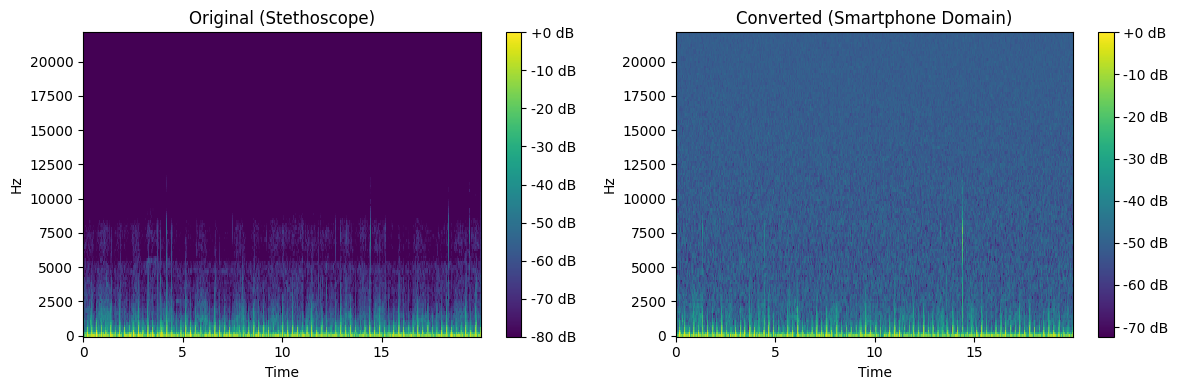

ESC 노이즈 적용 여부: False


In [7]:
# 결과 시각화 (원본 vs 변환)
import librosa.display
import matplotlib.pyplot as plt

sample_wav = wav_files[0]
original, sr = librosa.load(str(sample_wav), sr=None, mono=True)
converted, sr, esc_applied, esc_file = transfer_domain(str(sample_wav), esc50_files)

# mel-spectrogram 비교
def to_mel(audio, sr):
    mel = librosa.feature.melspectrogram(y=audio, sr=sr, n_mels=128, hop_length=512)
    return librosa.power_to_db(mel, ref=np.max)

mel_orig = to_mel(original, sr)
mel_conv = to_mel(converted, sr)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

img1 = librosa.display.specshow(mel_orig, sr=sr, hop_length=512, x_axis='time', y_axis='hz', ax=axes[0], cmap='viridis')
axes[0].set_title('Original (Stethoscope)')
fig.colorbar(img1, ax=axes[0], format='%+2.0f dB')

img2 = librosa.display.specshow(mel_conv, sr=sr, hop_length=512, x_axis='time', y_axis='hz', ax=axes[1], cmap='viridis')
axes[1].set_title('Converted (Smartphone Domain)')
fig.colorbar(img2, ax=axes[1], format='%+2.0f dB')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/lung_sound/eq_comparison_final.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'ESC 노이즈 적용 여부: {esc_applied}')
if esc_applied:
    print(f'사용된 ESC 파일: {esc_file}')